In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Regime Factor Rotation — Implementation Comparison

Loads standardized signal trades from `results/regime_factor_rotation_trades.csv`.

**Architecture:** Basket rotation (single capital pool, multiple concurrent positions,
MTM daily via `build_basket_equity`). On each monthly rebalance, `allocation` fraction
of current equity is split equally across the top-K new ETF positions.

**Methods:** Simple bet, Fixed Kelly.
(No risk-based: no stop-loss. No asset vol targeting: awkward for basket.)

**Leverage:** 1x, 2x, 4x, 8x. Kelly maps: Quarter=1x, Half=2x, Full=4x, Double=8x.


## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.implementations import build_basket_equity

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "Regime Factor Rotation"
SAVE_NAME     = "regime_factor_rotation"

pd.set_option("display.max_columns", None)


## 2. Load Signal Trades & Daily Prices

In [2]:
trades_all = pd.read_csv(f"results/{SAVE_NAME}_trades.csv",
                          parse_dates=["entry_time", "exit_time"])

# ── Schema validation ──
REQUIRED_COLS = ["entry_time", "exit_time", "direction", "instrument",
                 "entry_price", "exit_price", "pct_return_gross",
                 "exit_reason", "stop_price"]
missing = [c for c in REQUIRED_COLS if c not in trades_all.columns]
if missing:
    raise ValueError(
        f"results/{SAVE_NAME}_trades.csv is missing columns: {missing}\n"
        f"Found: {list(trades_all.columns)}\n"
        f"Re-run Regime_Factor_Rotation_Backtest.ipynb to regenerate."
    )

print(f"Loaded {len(trades_all)} trades")
print(f"Period: {trades_all['entry_time'].iloc[0].date()} -> {trades_all['exit_time'].iloc[-1].date()}")
print(f"By instrument: {dict(trades_all['instrument'].value_counts())}")
print(f"Avg hold days: {(trades_all['exit_time'] - trades_all['entry_time']).dt.days.mean():.1f}")

INSTRUMENTS = sorted(trades_all["instrument"].unique().tolist())
print(f"\n{len(INSTRUMENTS)} ETFs traded: {INSTRUMENTS}")

START_DATE = str(trades_all["entry_time"].iloc[0].date())
END_DATE   = str(trades_all["exit_time"].iloc[-1].date())

daily_data = fetch_historical_data(
    INSTRUMENTS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

daily_prices = {}
for sym in INSTRUMENTS:
    d = daily_data[sym].reset_index()
    d["date"] = pd.to_datetime(d["timestamp"]).dt.tz_localize(None).dt.normalize()
    daily_prices[sym] = d.set_index("date")["close"]
    print(f"{sym}: {len(daily_prices[sym])} daily bars")


Loaded 44 trades
Period: 2016-01-04 -> 2026-03-31
By instrument: {'COWZ': 13, 'VLUE': 13, 'MTUM': 7, 'SIZE': 6, 'QUAL': 5}
Avg hold days: 250.1

5 ETFs traded: ['COWZ', 'MTUM', 'QUAL', 'SIZE', 'VLUE']
Fetching COWZ...
  2,331 bars
Fetching MTUM...
  2,574 bars
Fetching QUAL...
  2,574 bars
Fetching SIZE...
  2,574 bars
Fetching VLUE...
  2,574 bars
COWZ: 2331 daily bars
MTUM: 2574 daily bars
QUAL: 2574 daily bars
SIZE: 2574 daily bars
VLUE: 2574 daily bars


## 3. Basket Engine

Thin wrapper around `build_basket_equity` that adds a `label` and uniform
stats formatting. No per-sleeve logic — basket builder handles MTM across
all concurrent positions directly.

In [3]:
def _portfolio_stats(daily_eq):
    daily_returns = daily_eq.pct_change().dropna()
    total_return = (daily_eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ann_sharpe = (daily_returns.mean() / daily_returns.std() * np.sqrt(252)
                   if daily_returns.std() > 0 else 0)
    peak = daily_eq.expanding().max()
    max_dd = ((daily_eq - peak) / peak).min() * 100
    years = (daily_eq.index[-1] - daily_eq.index[0]).days / 365.25
    cagr = ((daily_eq.iloc[-1] / STARTING_CAPITAL) ** (1 / years) - 1) * 100 if years > 0 else 0
    return {
        "total_return": round(total_return, 1),
        "cagr":         round(cagr, 2),
        "sharpe":       round(ann_sharpe, 2),
        "max_dd":       round(max_dd, 1),
    }

def run_basket(allocation, label):
    res = build_basket_equity(
        trades_all, daily_prices,
        starting_capital=STARTING_CAPITAL, allocation=allocation)
    return {
        "label":        label,
        "daily_equity": res["daily_equity"],
        "raw_result":   res,
        "stats":        _portfolio_stats(res["daily_equity"]),
    }

def print_portfolio_comparison(results):
    print(f"{'Label':<45} {'TotRet%':>12} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
    print("-" * 87)
    for r in results:
        s = r["stats"]
        print(f"{r['label']:<45} {s['total_return']:>12,.1f} {s['cagr']:>8.2f} "
              f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")


## 4. Base Sizing Comparison (1x)

Two methods at base leverage:
- **Simple bet 85%** — deploys 85% of equity into the top-K basket on each rebalance
- **Quarter Kelly** — Kelly f* computed from portfolio daily returns of the 85%-deployed
  run, then scaled by 0.25 for Quarter Kelly


In [4]:
# ── Compute Kelly f* from PORTFOLIO daily returns at base allocation ──
base_run = build_basket_equity(
    trades_all, daily_prices,
    starting_capital=STARTING_CAPITAL, allocation=0.85)
base_daily_returns = base_run["daily_equity"].pct_change().dropna()
wins_d = base_daily_returns[base_daily_returns > 0]
losses_d = base_daily_returns[base_daily_returns < 0]
if len(wins_d) >= 3 and len(losses_d) >= 3:
    p = len(wins_d) / len(base_daily_returns)
    b = wins_d.mean() / abs(losses_d.mean())
    KELLY_F = max((p * b - (1 - p)) / b, 0.01)
else:
    KELLY_F = 0.10
    p, b = 0.5, 1.0

print(f"Kelly f* from {len(base_daily_returns)} daily portfolio returns:")
print(f"  Daily win rate: {p*100:.1f}%, avg W/L ratio: {b:.2f}")
print(f"  Full Kelly f*: {KELLY_F:.2%}")
print(f"  Quarter={KELLY_F*0.25:.1%}, Half={KELLY_F*0.5:.1%}, "
      f"Full={KELLY_F:.1%}, Double={KELLY_F*2:.1%}\n")


Kelly f* from 2671 daily portfolio returns:
  Daily win rate: 52.6%, avg W/L ratio: 0.99
  Full Kelly f*: 4.63%
  Quarter=1.2%, Half=2.3%, Full=4.6%, Double=9.3%



In [5]:
r_simple = run_basket(allocation=0.85,
                        label="Simple bet 85% (1x)")
r_kelly  = run_basket(allocation=KELLY_F * 0.25,
                        label=f"Quarter Kelly {KELLY_F*0.25:.0%} (1x)")

base_results = [r_simple, r_kelly]
print("BASE COMPARISON (1x):\n")
print_portfolio_comparison(base_results)


BASE COMPARISON (1x):

Label                                              TotRet%    CAGR%   Sharpe   MaxDD%
---------------------------------------------------------------------------------------
Simple bet 85% (1x)                                  705.3    22.60     0.82    -55.2
Quarter Kelly 1% (1x)                                  4.8     0.46     0.81     -1.0


## 5. Leverage Sweep

Simple bet multiplies the 85% base allocation by leverage (so 2x = 170% gross).
Kelly levels map to: Quarter=1x, Half=2x, Full=4x, Double=8x.

In [6]:
KELLY_MAP = {1: 0.25, 2: 0.5, 4: 1.0, 8: 2.0}
KELLY_NAMES = {1: "Quarter", 2: "Half", 4: "Full", 8: "Double"}

LEVERAGE_LEVELS = [2, 4, 8]
sweep_results = {}

for lev in LEVERAGE_LEVELS:
    sweep_results[lev] = [
        run_basket(allocation=0.85 * lev,
                    label=f"Simple bet {int(85*lev)}% ({lev}x)"),
        run_basket(allocation=KELLY_F * KELLY_MAP[lev],
                    label=f"{KELLY_NAMES[lev]} Kelly {KELLY_F*KELLY_MAP[lev]:.0%} ({lev}x)"),
    ]

print("ALL METHODS AT 4x:\n")
print_portfolio_comparison(sweep_results[4])

print("\n\nSIMPLE BET -- SWEEP:")
print_portfolio_comparison([base_results[0]] + [sr[0] for sr in sweep_results.values()])

print("\nKELLY -- SWEEP (Quarter->Half->Full->Double):")
print_portfolio_comparison([base_results[1]] + [sr[1] for sr in sweep_results.values()])


ALL METHODS AT 4x:

Label                                              TotRet%    CAGR%   Sharpe   MaxDD%
---------------------------------------------------------------------------------------
Simple bet 340% (4x)                               5,474.4    48.11     0.18   -154.8
Full Kelly 5% (4x)                                    20.4     1.83     0.80     -4.1


SIMPLE BET -- SWEEP:
Label                                              TotRet%    CAGR%   Sharpe   MaxDD%
---------------------------------------------------------------------------------------
Simple bet 85% (1x)                                  705.3    22.60     0.82    -55.2
Simple bet 170% (2x)                               2,244.8    36.09     0.65    -92.9
Simple bet 340% (4x)                               5,474.4    48.11     0.18   -154.8
Simple bet 680% (8x)                               2,724.6    38.59     0.01   -262.8

KELLY -- SWEEP (Quarter->Half->Full->Double):
Label                                         

## 6. Equity Curves

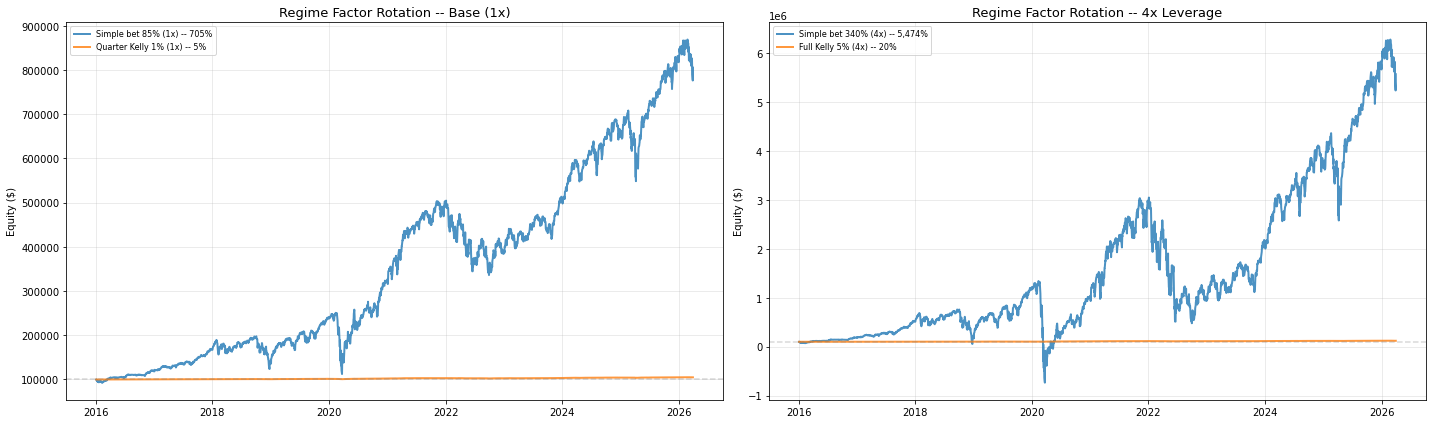

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

ax = axes[0]
for r in base_results:
    eq = r["daily_equity"]
    ret = (eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{r['label']} -- {ret:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- Base (1x)", fontsize=13)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")

ax = axes[1]
for r in sweep_results[4]:
    eq = r["daily_equity"]
    ret = (eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{r['label']} -- {ret:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- 4x Leverage", fontsize=13)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")

plt.tight_layout(); plt.show()


## 7. Per-ETF Contribution

P&L attribution by ETF under the base Simple bet 85% run.

PER-ETF CONTRIBUTION (Simple bet 85% base run):
-----------------------------------------------------------------
ETF        Trades    Total P&L $    Avg P&L $    WR %
-----------------------------------------------------------------
MTUM            7        231,610       33,087   85.7
QUAL            5        179,654       35,931   80.0
COWZ           13        165,197       12,707   92.3
SIZE            6         86,382       14,397   83.3
VLUE           13        -62,995       -4,846   61.5


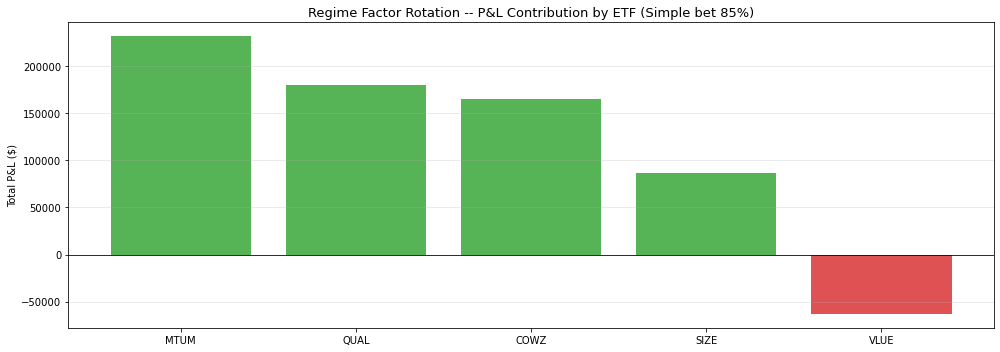

In [8]:
base_shares = base_run["shares_per_trade"]
trades_attr = trades_all.copy().reset_index(drop=True)
trades_attr["shares"] = base_shares
trades_attr["gross_pnl_$"] = trades_attr.apply(
    lambda t: t["shares"] * (t["exit_price"] - t["entry_price"])
              if t["direction"] == "long"
              else t["shares"] * (t["entry_price"] - t["exit_price"]), axis=1)

by_etf = trades_attr.groupby("instrument").agg(
    trades=("shares", "count"),
    total_pnl=("gross_pnl_$", "sum"),
    avg_pnl=("gross_pnl_$", "mean"),
    win_rate=("pct_return_gross", lambda s: (s > 0).mean() * 100),
).sort_values("total_pnl", ascending=False)

print("PER-ETF CONTRIBUTION (Simple bet 85% base run):")
print("-" * 65)
print(f"{'ETF':<8} {'Trades':>8} {'Total P&L $':>14} {'Avg P&L $':>12} {'WR %':>7}")
print("-" * 65)
for sym, row in by_etf.iterrows():
    print(f"{sym:<8} {int(row['trades']):>8} {row['total_pnl']:>14,.0f} "
          f"{row['avg_pnl']:>12,.0f} {row['win_rate']:>6.1f}")

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["C2" if v > 0 else "C3" for v in by_etf["total_pnl"]]
ax.bar(by_etf.index, by_etf["total_pnl"], color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{STRATEGY_NAME} -- P&L Contribution by ETF (Simple bet 85%)", fontsize=13)
ax.set_ylabel("Total P&L ($)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 8. Save

In [9]:
import os, json

def _key(label):
    return (label.lower().replace(" ", "_").replace("(", "").replace(")", "")
             .replace("%", "pct").replace("=", "").replace(",", "")
             .replace("--", ""))

os.makedirs("results", exist_ok=True)

impl_summary = {}
all_results = base_results[:]
for results in sweep_results.values():
    all_results.extend(results)

for r in all_results:
    k = _key(r["label"])
    impl_summary[k] = dict(r["stats"])
    impl_summary[k]["label"] = r["label"]

viable = [r for r in all_results if r["stats"]["max_dd"] > -50]
if viable:
    best = max(viable, key=lambda r: r["stats"]["sharpe"])
    impl_summary["_recommended"] = best["label"]
    print(f"Recommended: {best['label']}")
    print(f"  Sharpe={best['stats']['sharpe']}, Return={best['stats']['total_return']}%,"
          f" MaxDD={best['stats']['max_dd']}%, CAGR={best['stats']['cagr']}%")

with open(f"results/{SAVE_NAME}_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved {len(impl_summary) - 1} implementations")

eq_dir = f"results/{SAVE_NAME}_daily_equity"
os.makedirs(eq_dir, exist_ok=True)
for r in all_results:
    r["daily_equity"].to_csv(f"{eq_dir}/{_key(r['label'])}.csv")
print(f"Saved {len(all_results)} daily equity curves -> {eq_dir}/")


Recommended: Quarter Kelly 1% (1x)
  Sharpe=0.81, Return=4.8%, MaxDD=-1.0%, CAGR=0.46%

Saved 8 implementations
Saved 8 daily equity curves -> results/regime_factor_rotation_daily_equity/
